# Supervised Learning Capstone Project - Cohort Analysis & Customer Churn Predictions (using Tree Methods)



### Goal of this project is to create a model to predict whether or not a customer will Churn.


# <a name='data'>Data</a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


-----

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
numerics_columns = df.select_dtypes(exclude='object')
categorical_columns = df.select_dtypes(include='object')

In [ ]:
numerics_columns.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
categorical_columns.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [ ]:
numerics_columns.head(2)

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95


In [ ]:
categorical_columns.head(2)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No


In [ ]:
categorical_columns = pd.concat([categorical_columns, numerics_columns['SeniorCitizen']], axis=1)

In [ ]:
categorical_columns = categorical_columns.drop(['customerID'], axis=1)

In [ ]:
categorical_columns.head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn,SeniorCitizen
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,0
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No,0
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes,0
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No,0
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes,0


In [ ]:
numerics_columns = numerics_columns.drop('SeniorCitizen', axis=1)
numerics_columns.head(2)

,tenure,MonthlyCharges
0,1,29.85
1,34,56.95


In [ ]:
numerics_columns.columns

Index(['tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
categorical_columns.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn',
       'SeniorCitizen'],
      dtype='object')

-----

#Exploratory Data Analysis</a>

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
5163 / len(df), 1869/len(df)

(0.7330682947607554, 0.2653698707936959)

/tmp/ipython-input-2789448916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


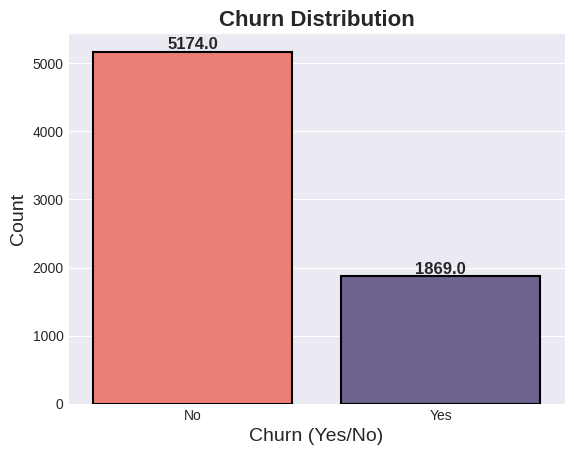

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
custom_colors = ['#FF6F61', '#6B5B95']

sns.countplot(
    data=df,
    x='Churn',
    palette=custom_colors,
    edgecolor='black',
    linewidth=1.5
)
plt.title("Churn Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Churn (Yes/No)", fontsize=14)
plt.ylabel("Count", fontsize=14)

for p in plt.gca().patches:
    plt.annotate(
        format(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

plt.show()


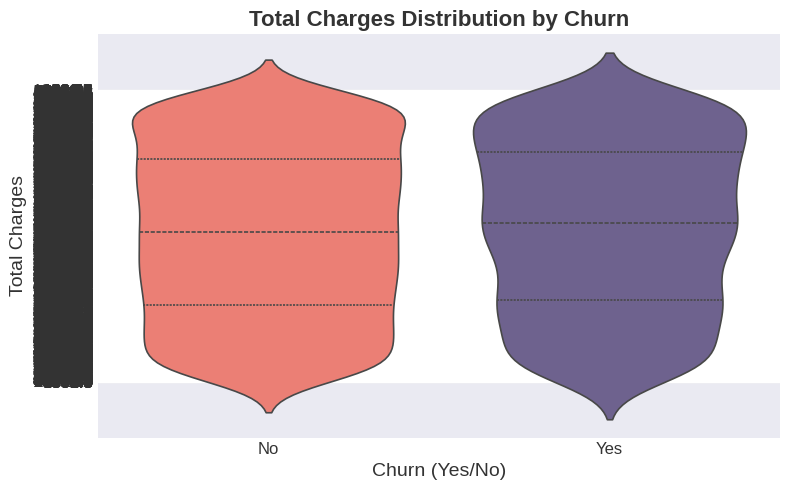

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
custom_colors = ['#FF6F61', '#6B5B95']
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='Churn',
    y='TotalCharges',
    hue='Churn',
    palette=custom_colors,
    inner='quartile',
    linewidth=1.2,
    legend=False
)

plt.title("Total Charges Distribution by Churn",
          fontsize=16, fontweight='bold', color='#333333')
plt.xlabel("Churn (Yes/No)",
           fontsize=14, color='#333333')
plt.ylabel("Total Charges",
           fontsize=14, color='#333333')
plt.xticks(color='#333333', fontsize=12)
plt.yticks(color='#333333', fontsize=12)
plt.tight_layout()
plt.show()


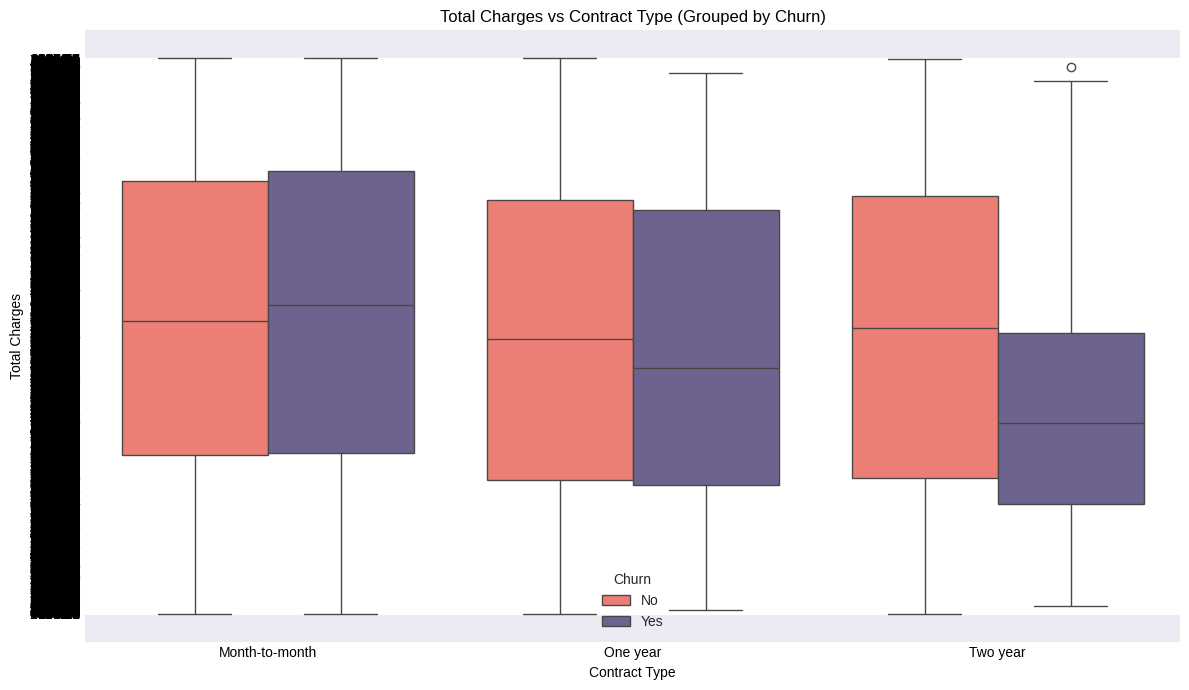

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
custom_colors = ['#FF6F61', '#6B5B95']
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x='Contract',
    y='TotalCharges',
    hue='Churn',
    palette=custom_colors
)
plt.xlabel("Contract Type", color='black')
plt.ylabel("Total Charges", color='black')
plt.title("Total Charges vs Contract Type (Grouped by Churn)", color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


In [ ]:
categorical_columns.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn',
       'SeniorCitizen'],
      dtype='object')

In [ ]:
corr_df = pd.get_dummies(df[['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']]).corr()

In [ ]:
corr_yes_churn = corr_df['Churn_Yes'].sort_values()[1: -1]
corr_yes_churn

,Churn_Yes
Contract_Two year,-0.302253
InternetService_No,-0.227890
DeviceProtection_No internet service,-0.227890
TechSupport_No internet service,-0.227890
OnlineSecurity_No internet service,-0.227890
StreamingMovies_No internet service,-0.227890
StreamingTV_No internet service,-0.227890
OnlineBackup_No internet service,-0.227890
PaperlessBilling_No,-0.191825
Contract_One year,-0.177820


/tmp/ipython-input-793033122.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


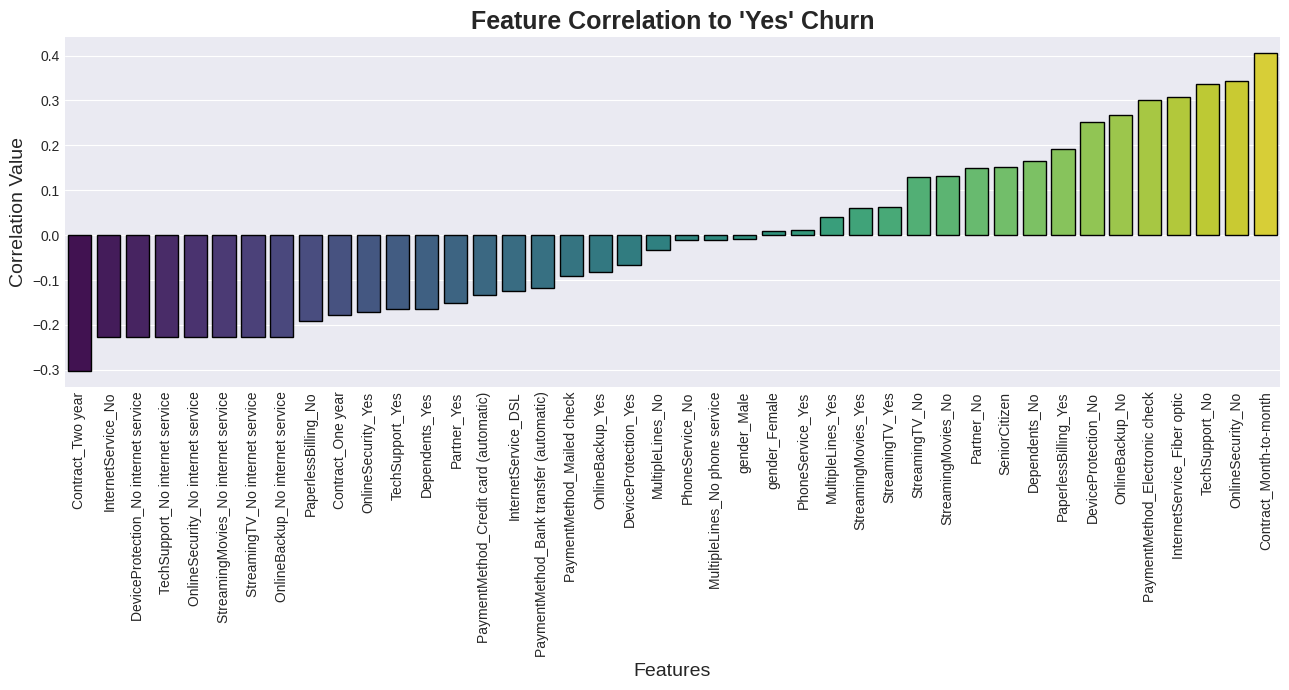

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
colors = sns.color_palette("viridis", len(corr_yes_churn))

plt.figure(figsize=(13, 7))

sns.barplot(
    x=corr_yes_churn.index,
    y=corr_yes_churn.values,
    palette=colors,
    edgecolor='black'
)

plt.title("Feature Correlation to 'Yes' Churn", fontsize=18, fontweight='bold')
plt.xlabel("Features", fontsize=14)
plt.ylabel("Correlation Value", fontsize=14)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


 # <a name='churnanalysis'> Churn Analysis</a>



## What are the 3 contract types available?

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


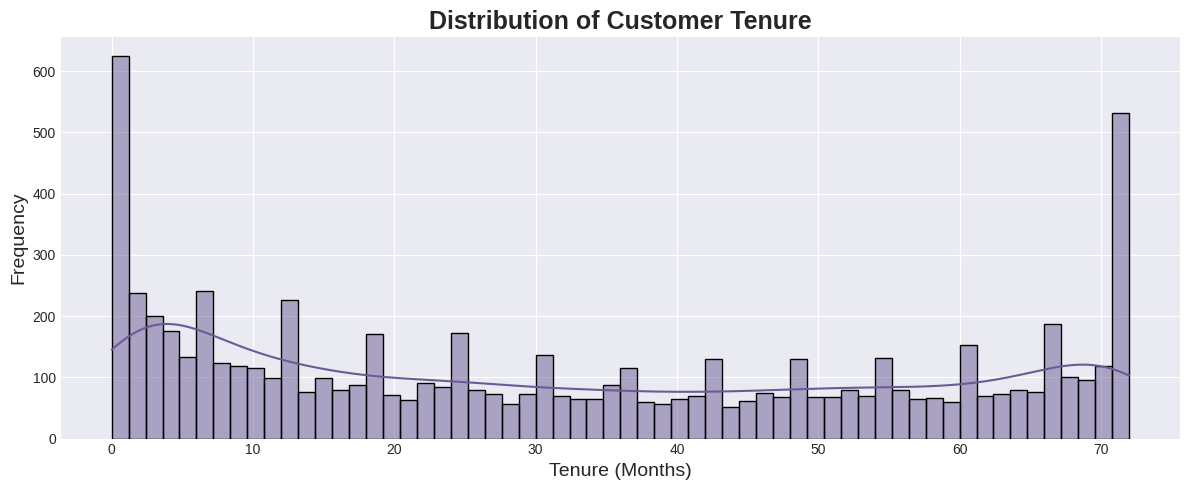

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x='tenure',
    bins=60,
    kde=True,
    color="#6B5B95",
    edgecolor='black',
    linewidth=1
)

plt.title("Distribution of Customer Tenure", fontsize=18, fontweight='bold')
plt.xlabel("Tenure (Months)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.tight_layout()
plt.show()


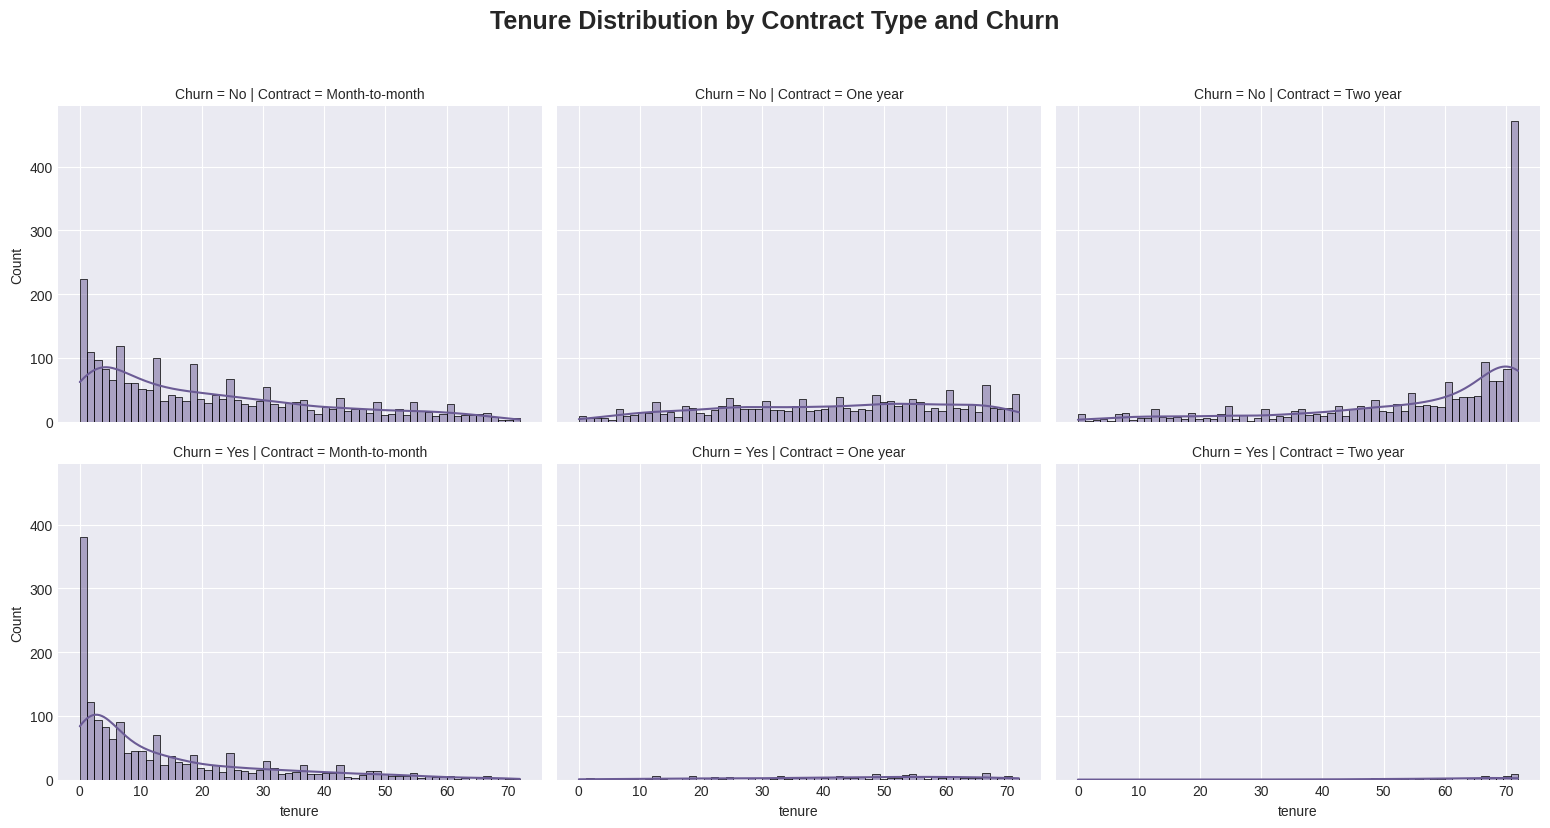

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
palette = ["#6B5B95", "#FF6F61"]

g = sns.displot(
    data=df,
    x='tenure',
    col='Contract',
    row='Churn',
    bins=60,
    kde=True,
    color="#6B5B95",
    height=4,
    aspect=1.3
)
g.fig.suptitle("Tenure Distribution by Contract Type and Churn",
               fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


In [ ]:
numerics_columns.columns

Index(['tenure', 'MonthlyCharges'], dtype='object')

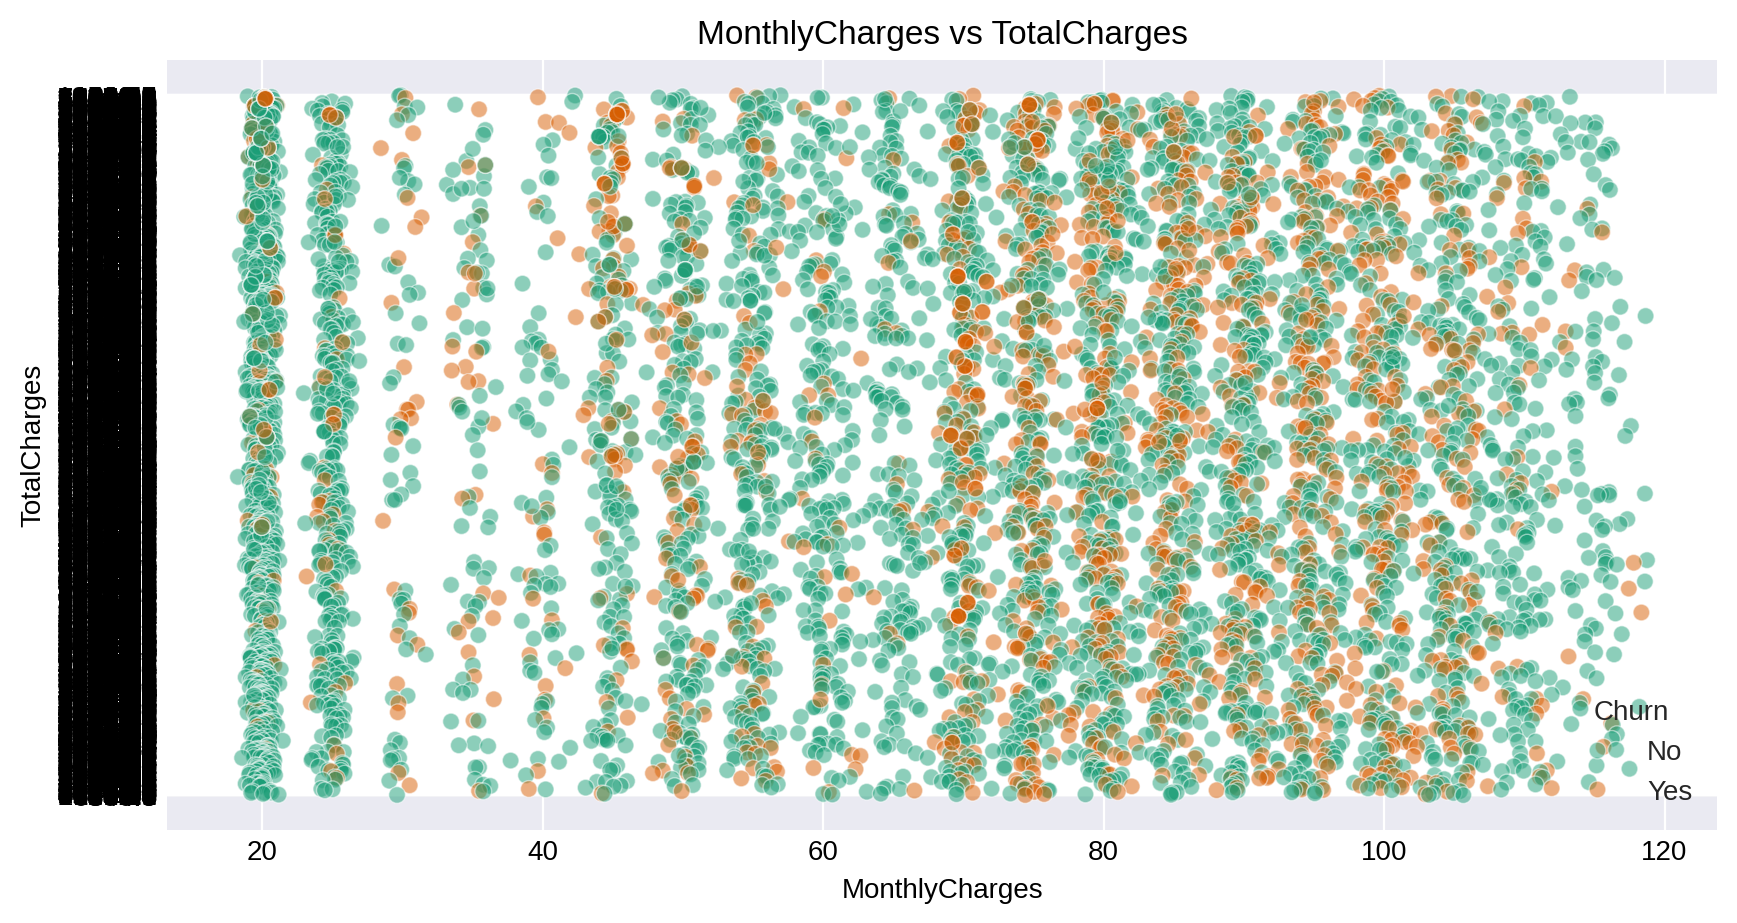

In [ ]:
plt.figure(figsize=(10, 5), dpi=200)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges',
                hue='Churn', palette='Dark2', alpha=0.5, linewidth=0.5)
plt.xlabel("MonthlyCharges", color='black')
plt.ylabel("TotalCharges", color='black')
plt.title("MonthlyCharges vs TotalCharges", color='black')
plt.xticks(color='black')
plt.yticks(color='black')

plt.legend(title="Churn")
plt.show()


In [ ]:
unique_tenures = sorted(df['tenure'].unique())
unique_tenures[:5], unique_tenures[-5:]

([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)],
 [np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72)])

In [ ]:
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']

In [ ]:
churn_rate = 100 * yes_churn / (no_churn + yes_churn)

In [ ]:
churn_rate.transpose()['customerID']

,customerID
tenure,
0,NaN
1,61.990212
2,51.680672
3,47.000000
4,47.159091
...,...
68,9.000000
69,8.421053
70,9.243697


In [ ]:
total_churns_by_tenure = df[df['Churn'] == 'Yes'].groupby('tenure').count()['customerID']
total_churns_by_tenure.head()

,customerID
tenure,
1,380
2,123
3,94
4,83
5,64


In [ ]:
total_customers_by_tenure = df.groupby('tenure').count()['customerID']
total_customers_by_tenure

,customerID
tenure,
0,11
1,613
2,238
3,200
4,176
...,...
68,100
69,95
70,119


In [ ]:
churn_rates_by_tenure = 100* total_churns_by_tenure / total_customers_by_tenure

In [ ]:
churn_rates_by_tenure

,customerID
tenure,
0,NaN
1,61.990212
2,51.680672
3,47.000000
4,47.159091
...,...
68,9.000000
69,8.421053
70,9.243697


### <a name='cohorts_vis'>Visualization of Churn Rate per tenure group 1-72 months</a>

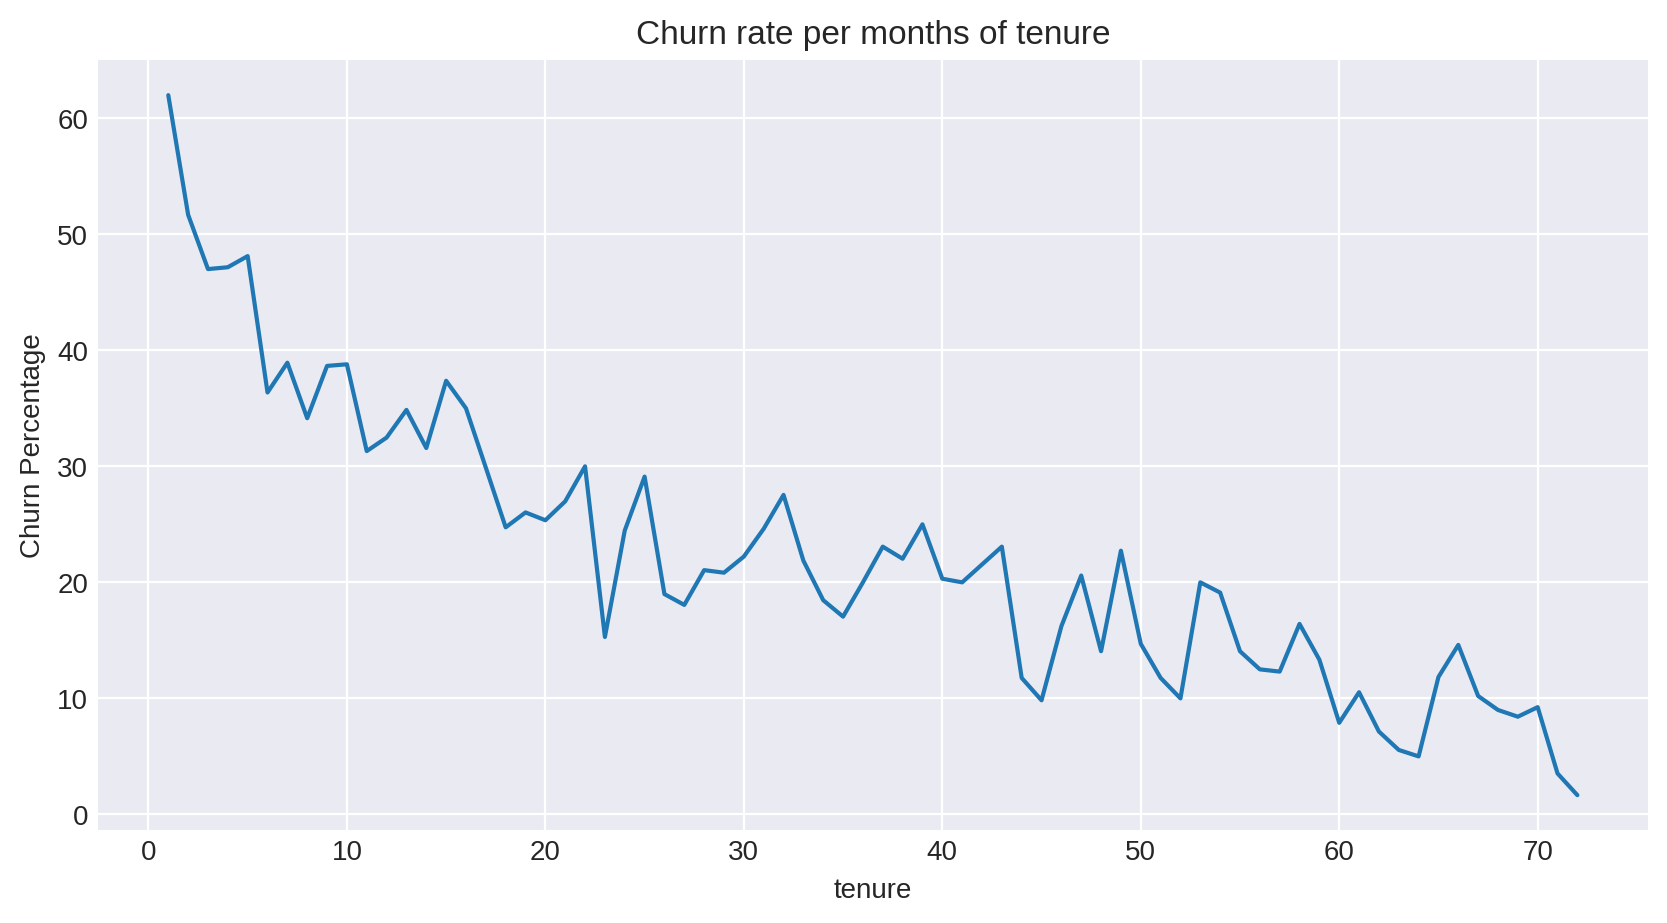

In [ ]:
plt.figure(figsize=(10, 5), dpi=200)
churn_rates_by_tenure.plot();
plt.ylabel('Churn Percentage')
plt.title('Churn rate per months of tenure');

In [ ]:
def cohort_group(tenure):
    if tenure < 13:
        return '0-12 Months'
    elif tenure < 25:
        return '12-24 Months'
    elif tenure < 49:
        return '24-48 Months'
    return "Over 48 Months"

In [ ]:
df['Tenure Cohort'] = df['tenure'].apply(cohort_group)

In [ ]:
df[['tenure','Tenure Cohort']].head()

,tenure,Tenure Cohort
0,1,0-12 Months
1,34,24-48 Months
2,2,0-12 Months
3,45,24-48 Months
4,2,0-12 Months


-----------

## <a name='vis_toal_monthly'>Visualization of Total Charges vs Monthly Charts</a>

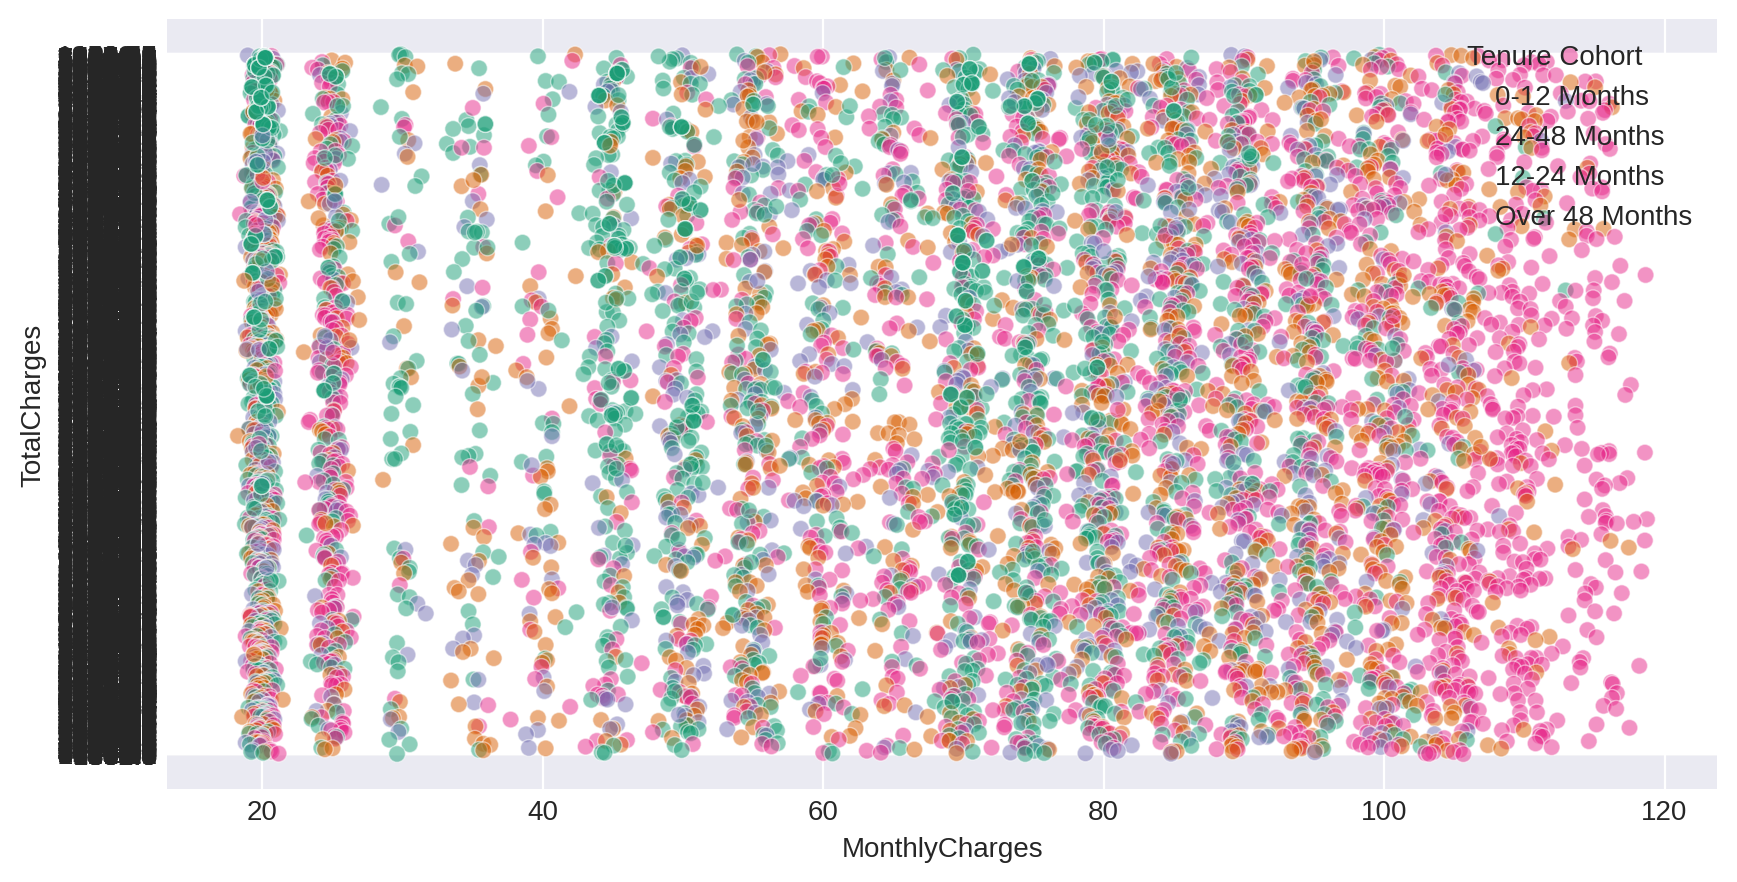

In [ ]:
plt.figure(figsize=(10, 5), dpi=200)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Tenure Cohort', linewidth=0.5, alpha=0.5, palette='Dark2');


-------

## <a name='churn_count_cohort'>Churn Count per Cohort Group</a>

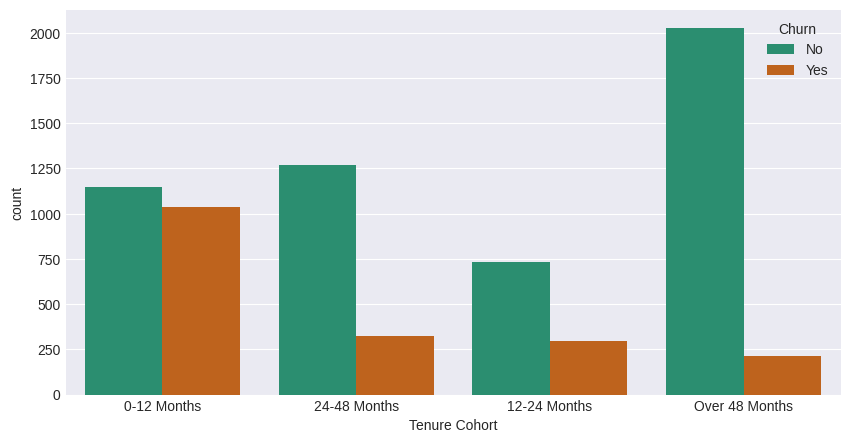

In [ ]:
plt.figure(figsize=(10, 5), dpi=100)
sns.countplot(data=df, x='Tenure Cohort', hue='Churn', palette='Dark2');

## <a name='vis_tenure_contract_churn'>Visualization of Tenure Cohort, separated out by contract type and Churn</a>

<Figure size 2000x800 with 0 Axes>

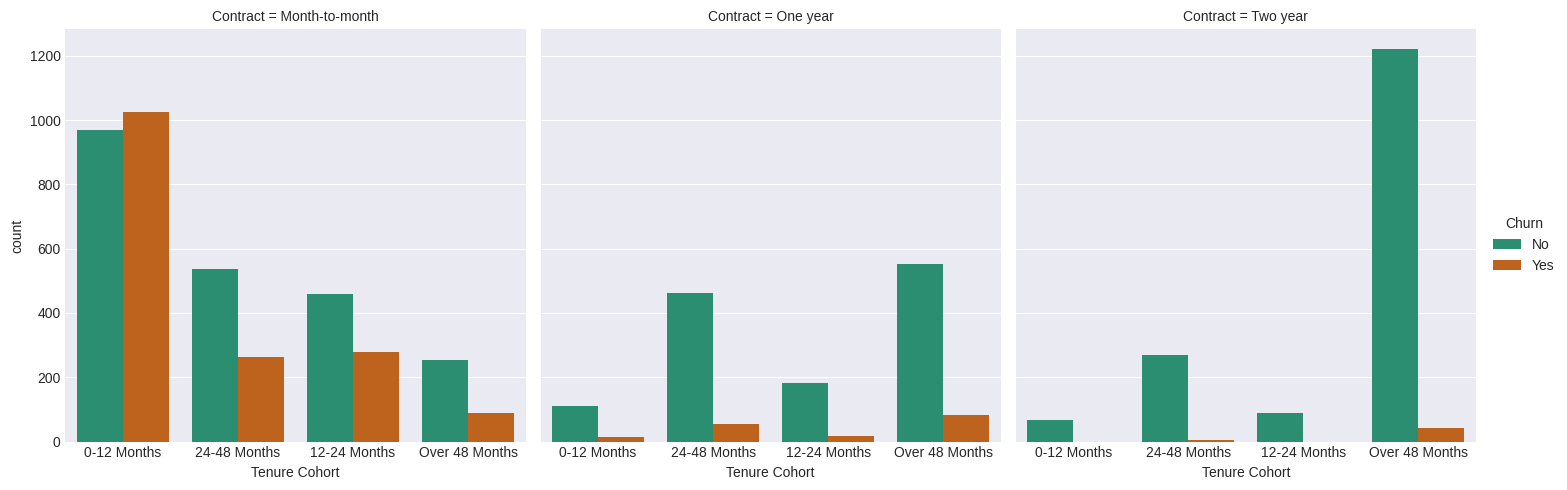

In [ ]:
plt.figure(figsize=(10,4),dpi=200)
sns.catplot(data=df, x='Tenure Cohort', col='Contract', kind='count', hue='Churn', palette='Dark2');


-----

# <a name='modelling'>Predictive Modeling</a>


## <a name='decisiontree'>Single Decision Tree</a>

## Features and Labels separation, Categorical Encoding

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Tenure Cohort'],
      dtype='object')

In [ ]:
X = df.drop(['customerID', 'Churn'], axis=1)
X = pd.get_dummies(X, drop_first=True)

In [ ]:
y = df['Churn']

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=101)

In [ ]:
X_train.shape, X_test.shape, X_val.shape

((5634, 6562), (704, 6562), (705, 6562))

## Modelling

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
paramaters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(5,50,1),
    'max_features': ['auto', 'sqrt', 'log2'],
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), paramaters, cv=5)

In [ ]:
dt_grid = GridSearchCV(DecisionTreeClassifier(), paramaters, cv=5).fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
450 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
450 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

In [ ]:
dt_grid.best_params_

{'criterion': 'entropy', 'max_depth': np.int64(34), 'max_features': 'sqrt'}

In [ ]:
dt_grid.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(34),
                       max_features='sqrt')

### Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
dt_predictions = dt_grid.predict(X_test)

In [ ]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

          No       0.79      0.89      0.84       516
         Yes       0.55      0.36      0.43       188

    accuracy                           0.75       704
   macro avg       0.67      0.62      0.64       704
weighted avg       0.73      0.75      0.73       704



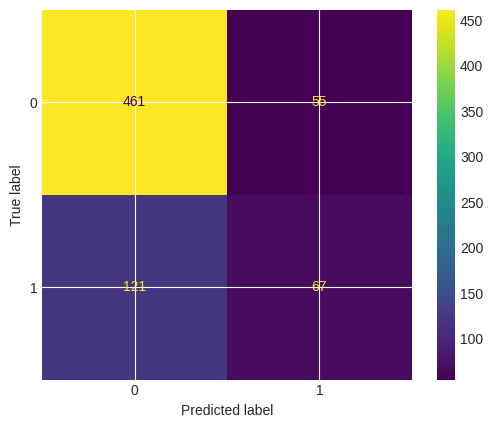

In [ ]:
cm = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm).plot()
plt.show()


### Feature importances

In [ ]:
dt_grid.best_estimator_.feature_importances_

array([0.02079393, 0.03042027, 0.13516941, ..., 0.01181375, 0.03428301,
       0.11103212])

In [ ]:
imp_features = pd.DataFrame(data=dt_grid.best_estimator_.feature_importances_,
                                               index=X.columns,
                                               columns=['Feature Imporance'])

In [ ]:
imp_features.sort_values('Feature Imporance', ascending=False)

,Feature Imporance
MonthlyCharges,0.135169
Tenure Cohort_Over 48 Months,0.111032
Tenure Cohort_24-48 Months,0.034283
TechSupport_Yes,0.031473
Contract_Two year,0.031376
...,...
TotalCharges_2874.15,0.000000
TotalCharges_2874.45,0.000000
TotalCharges_2877.05,0.000000
TotalCharges_2877.95,0.000000


In [ ]:
imp_features = imp_features[imp_features['Feature Imporance']  > 0].sort_values('Feature Imporance')

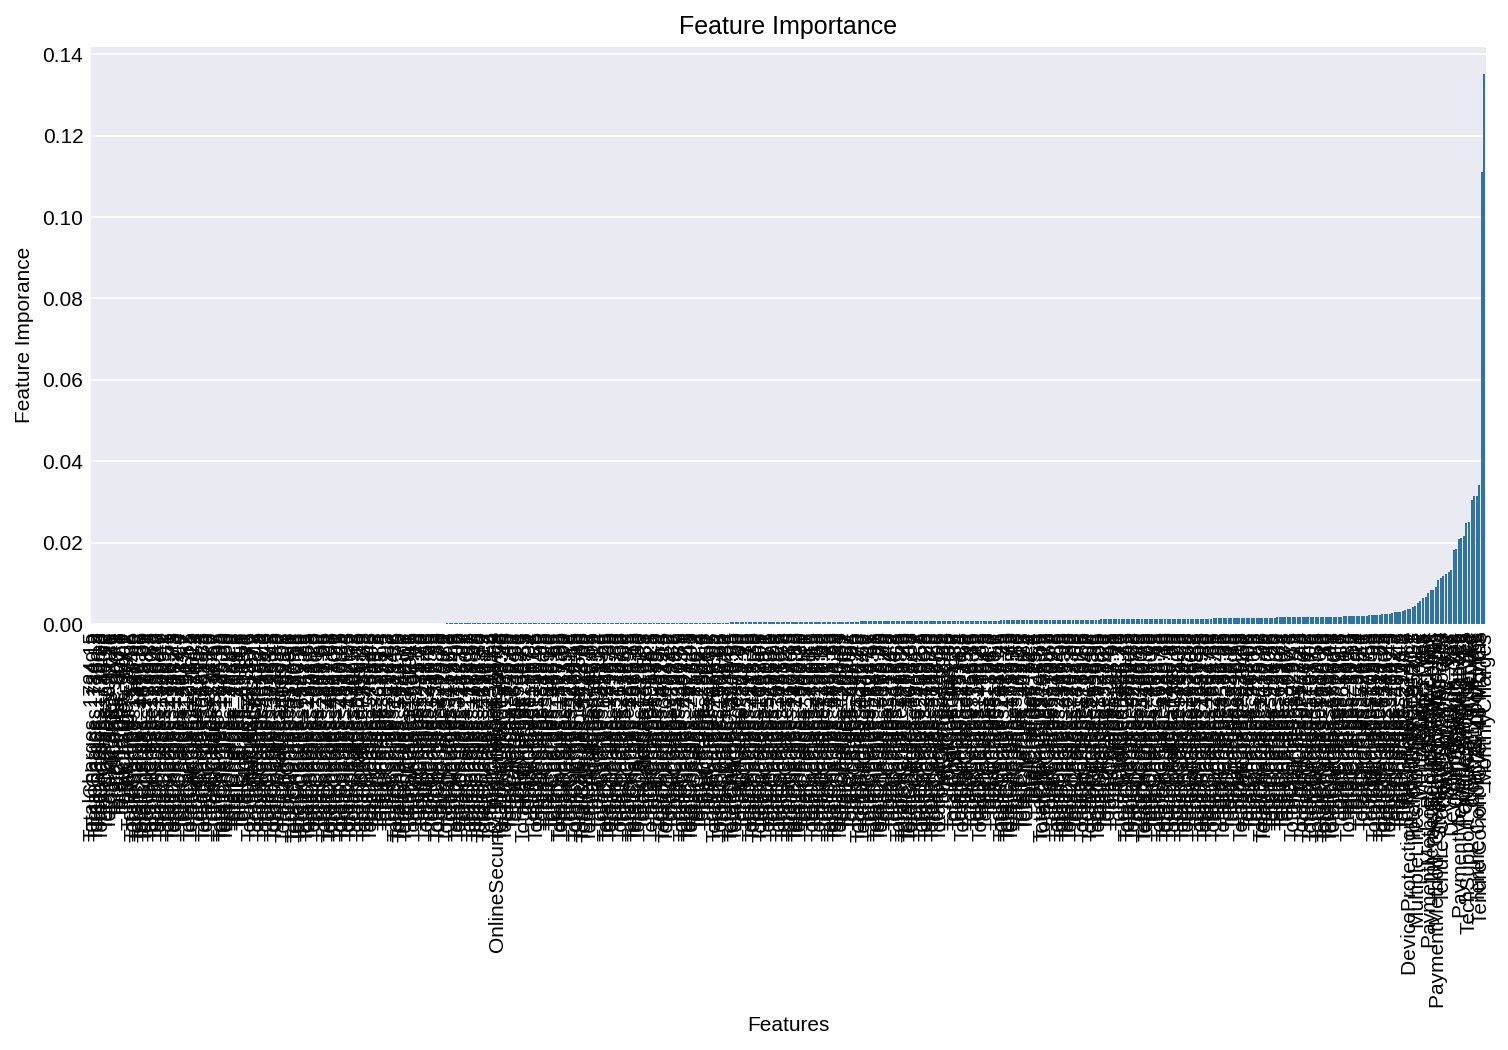

In [ ]:
plt.figure(figsize=(12, 5), dpi=150)

sns.barplot(data=imp_features, x=imp_features.index, y='Feature Imporance')

plt.xticks(rotation=90, color='black')
plt.yticks(color='black')

plt.xlabel("Features", color='black')
plt.ylabel("Feature Imporance", color='black')
plt.title("Feature Importance", color='black')

plt.show()


In [ ]:
from sklearn.tree import plot_tree

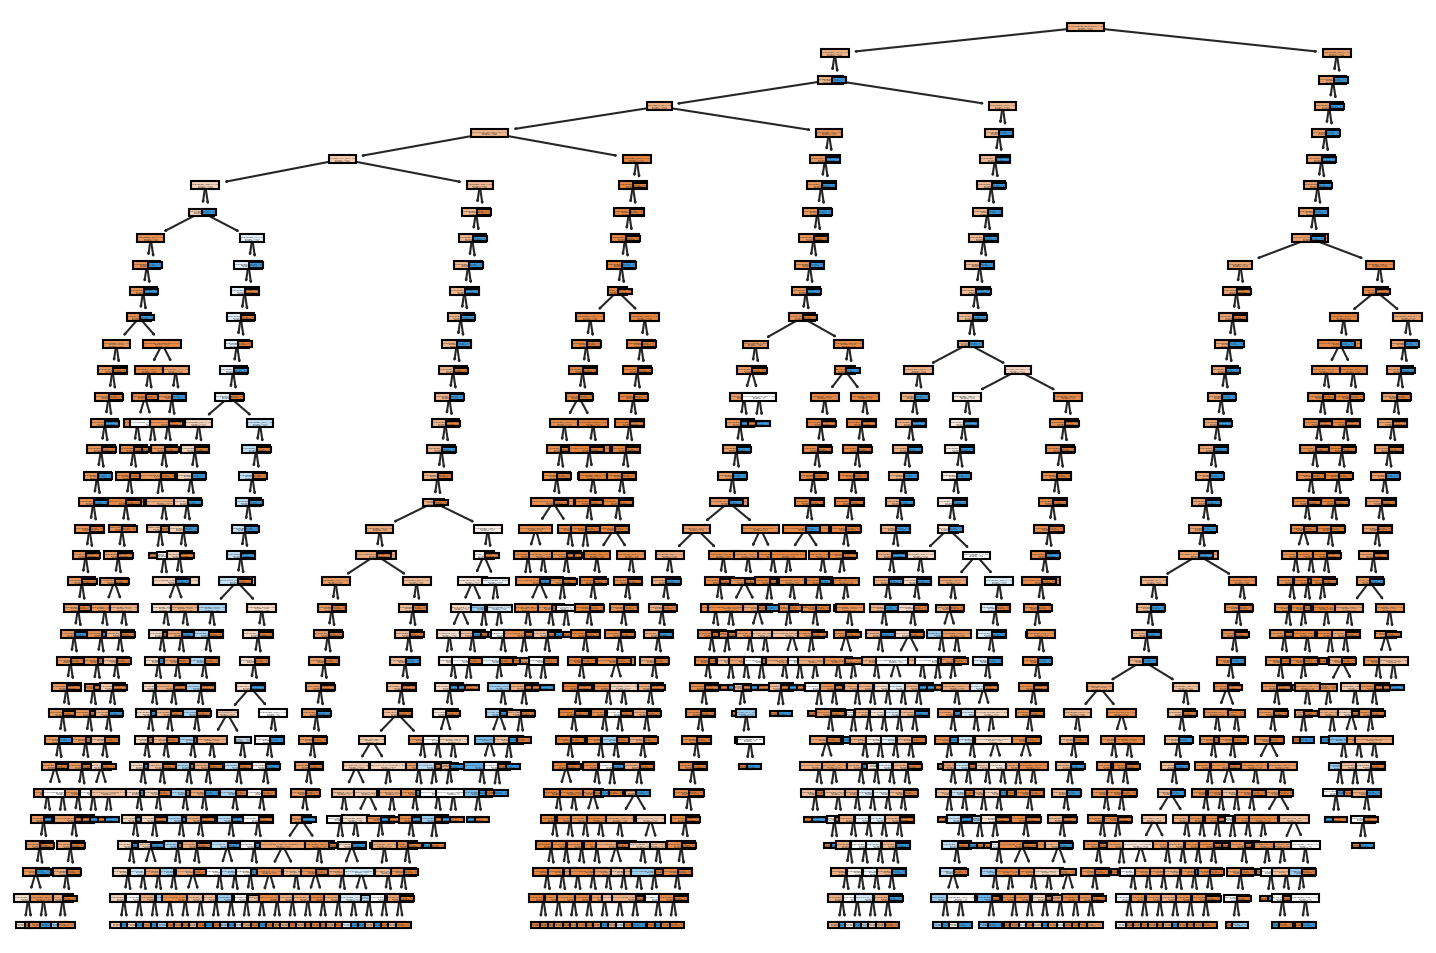

In [ ]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(dt_grid.best_estimator_, filled=True, feature_names=X.columns);

## <a name='randomforest'>Random Forest</a>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
parameters = {
    'n_estimators': [1, 2, 4, 8, 16, 32, 64, 100, 200, 300],
    'max_features': ["auto", "sqrt", "log2"],
}

rf_grid = GridSearchCV(RandomForestClassifier(), parameters, cv=5, verbose=2, n_jobs=-1)

In [ ]:
param_grid = {
    'n_estimators': [1, 2, 4, 8, 16, 32, 64, 100, 200, 300],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train.to_numpy())


Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_features': ['sqrt', 'log2'],
                         'n_estimators': [1, 2, 4, 8, 16, 32, 64, 100, 200,
                                          300]},
             verbose=2)

In [ ]:
rf_grid.best_estimator_

RandomForestClassifier(max_features='log2')

In [ ]:
rf_grid.best_params_

{'max_features': 'log2', 'n_estimators': 100}

In [ ]:
rf_predictions = rf_grid.predict(X_test)

In [ ]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

          No       0.80      0.92      0.86       516
         Yes       0.65      0.38      0.48       188

    accuracy                           0.78       704
   macro avg       0.73      0.65      0.67       704
weighted avg       0.76      0.78      0.76       704



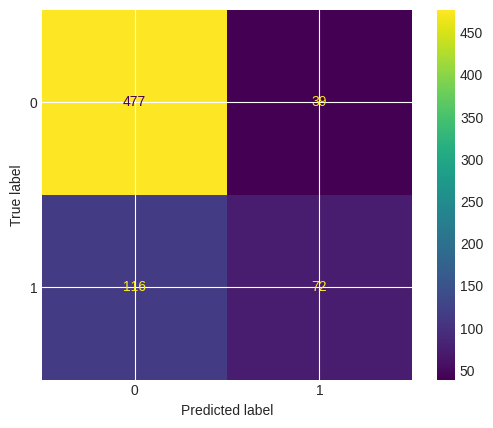

In [ ]:
y_pred = rf_grid.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


## <a name='boosted'>Boosted Trees with Ada Boost and Gradient Boost</a>

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

# Ada Boost

In [ ]:
ada_model = AdaBoostClassifier()

In [ ]:
gb_model = GradientBoostingClassifier()

In [ ]:
parameters = {
    'n_estimators': [50, 100, 150, 200]
}

ada_grid = GridSearchCV(ada_model, parameters, cv=3, n_jobs=-1)

ada_grid.fit(X_train, y_train.to_numpy())


GridSearchCV(cv=3, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'n_estimators': [50, 100, 150, 200]})

In [ ]:
ada_predictions = ada_grid.predict(X_test)

print(classification_report(y_test, ada_predictions))

              precision    recall  f1-score   support

          No       0.82      0.91      0.86       516
         Yes       0.65      0.46      0.54       188

    accuracy                           0.79       704
   macro avg       0.74      0.69      0.70       704
weighted avg       0.78      0.79      0.78       704



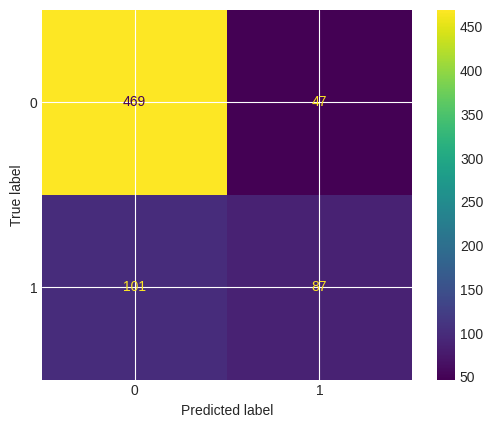

In [ ]:
y_pred = ada_grid.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


# Gradient Boost

In [ ]:
gb_grid = GridSearchCV(gb_model, parameters, cv=5)
gb_grid.fit(X_train, y_train.to_numpy())


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'n_estimators': [50, 100, 150, 200]})

In [ ]:
gb_predictions = gb_grid.predict(X_test)

print(classification_report(y_test, gb_predictions))

              precision    recall  f1-score   support

          No       0.83      0.93      0.88       516
         Yes       0.70      0.48      0.57       188

    accuracy                           0.81       704
   macro avg       0.77      0.70      0.72       704
weighted avg       0.80      0.81      0.79       704



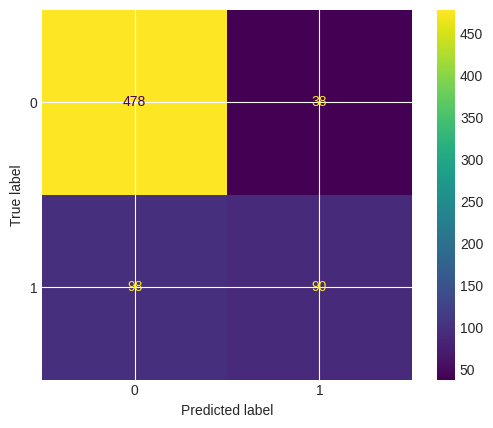

In [ ]:
y_pred = gb_grid.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


# <a name='final_model'>Final Model Selection and Evaluation</a>

In [ ]:
ada_predictions_val = ada_grid.predict(X_val)

In [ ]:
print(classification_report(y_val, ada_predictions_val))

              precision    recall  f1-score   support

          No       0.81      0.92      0.86       510
         Yes       0.67      0.45      0.54       195

    accuracy                           0.79       705
   macro avg       0.74      0.68      0.70       705
weighted avg       0.77      0.79      0.77       705



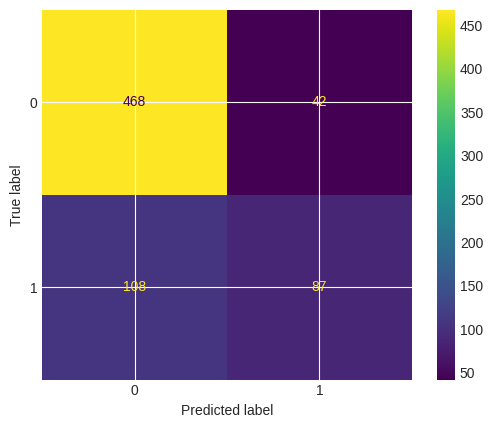

In [ ]:
y_pred = ada_grid.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()
